# Etapa 1 - Buscador de imagenes por similitud

Notebook de trabajo de la Etapa 1: extraccion de embeddings con un
modelo pre-entrenado en ImageNet, construccion de la base vectorial,
busqueda por similitud y prediccion de raza por vecinos.

Requisitos previos:
- `extract_embedding`, `search_similar_images` y
  `predict_breed_from_neighbors` implementadas en
  `src/lib/services/similarity_service.py`

Backend de base vectorial utilizado en esta notebook: JSON
(`EmbeddingStore`), por no contar con un servidor PostgreSQL en Colab, pero se puede correr perfectamente
con pgvector en el entorno local.

## Equipo
- Agustín Accurso 
- Lautaro Cena

## 1. Preparación del entorno

Como este notebook corre tanto en Google Colab (clonando el repo y
descargando el dataset) como en un entorno local ya clonado (donde
esos pasos ya estan hechos). La variable `IN_COLAB` controla que
celdas se ejecutan.

Se utiliza pgvector (PostgreSQL) como backend de la base vectorial,
validado en el entorno local junto a Docker. En Google Colab, donde
no hay un servidor PostgreSQL disponible, esta misma notebook corre
intercambiando a `USE_PGVECTOR=false` (backend JSON), sin cambios de
codigo, gracias a la abstraccion `EmbeddingStoreProtocol`. La
configuracion se define por variables de entorno antes de importar
`lib`.

In [23]:
import sys
print(sys.executable)

c:\Users\IKON\AppData\Local\Programs\Python\Python312\python.exe


In [24]:
import os
import sys
import json
import zipfile
import subprocess
import urllib.request
from pathlib import Path

# Detectar el entorno antes de instalar dependencias,
# localizar el proyecto o importar módulos internos.
IN_COLAB = "google.colab" in sys.modules

# En Colab no se dispone del servidor PostgreSQL del proyecto.
# En local, USE_PGVECTOR debe provenir del archivo .env.
if IN_COLAB:
    os.environ["USE_PGVECTOR"] = "false"

print(f"Entorno detectado: {'Google Colab' if IN_COLAB else 'local'}")

Entorno detectado: local


### Instalación e importacion de librerias

In [25]:
if IN_COLAB:
    import subprocess, sys
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "pydantic-settings",
        "python-dotenv",
        "kagglehub",
    ])
else:
    print("Entorno local: dependencias ya instaladas via requirements.txt en el .venv.")

Entorno local: dependencias ya instaladas via requirements.txt en el .venv.


### Clonar el repositorio y definir el backend de la base de datos

In [26]:
REPO_URL = "https://github.com/accursoagus/tuia-dog-recognition-app.git"


def find_project_root(start_path: Path) -> Path:
    """
    Busca la raíz del proyecto verificando que existan
    las carpetas src y scripts.
    """
    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        if (
            (candidate / "src").is_dir()
            and (candidate / "scripts").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "No se encontró la raíz del proyecto. "
        "La carpeta debe contener los directorios 'src' y 'scripts'."
    )


if IN_COLAB:
    colab_project_path = Path("/content/proyecto")

    if not colab_project_path.exists():
        subprocess.run(
            [
                "git",
                "clone",
                REPO_URL,
                str(colab_project_path),
            ],
            check=True,
        )
    else:
        print(
            "El repositorio ya existe en Colab; "
            "se reutiliza la carpeta actual."
        )

    PROJECT_ROOT = colab_project_path

else:
    PROJECT_ROOT = find_project_root(Path.cwd())


SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))


# Se replica el mismo criterio utilizado por build_index.py:
# si existe src/.env, las configuraciones y paths relativos
# deben cargarse desde la carpeta src.
if (SRC_PATH / ".env").is_file():
    CONFIG_WORKDIR = SRC_PATH
else:
    CONFIG_WORKDIR = PROJECT_ROOT

os.chdir(CONFIG_WORKDIR)


from lib.config import settings
from lib.bootstrap import build_store, build_similarity


import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Directorio de configuración: {CONFIG_WORKDIR}")
print(f"Archivo src/.env presente: {(SRC_PATH / '.env').is_file()}")

Raíz del proyecto: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app
Directorio de configuración: C:\Users\IKON\Desktop\tp2-CV\tuia-dog-recognition-app
Archivo src/.env presente: False


In [27]:
backend_name = "pgvector" if settings.use_pgvector else "JSON"

print("Configuración efectiva del proyecto:")
print(f"- Entorno: {'Google Colab' if IN_COLAB else 'local'}")
print(f"- Backend de base vectorial: {backend_name}")
print(f"- Dataset: {settings.dataset_path}")
print(f"- GPU disponible: {torch.cuda.is_available()}")

Configuración efectiva del proyecto:
- Entorno: local
- Backend de base vectorial: JSON
- Dataset: data\dataset
- GPU disponible: False


### Descargar el dataset

In [28]:
dataset_download_script = (
    PROJECT_ROOT
    / "scripts"
    / "download_dataset.py"
)


if IN_COLAB or not (
    settings.dataset_path / "train"
).is_dir():
    subprocess.run(
        [
            sys.executable,
            str(dataset_download_script),
        ],
        check=True,
        cwd=CONFIG_WORKDIR,
    )

else:
    print(
        "Entorno local: dataset ya presente, "
        "se omite la descarga."
    )


if settings.dataset_path.is_dir():
    print(
        "Splits disponibles:",
        sorted(
            path.name
            for path in settings.dataset_path.iterdir()
        ),
    )
else:
    print(
        f"No se encontró el dataset en: "
        f"{settings.dataset_path}"
    )

Entorno local: dataset ya presente, se omite la descarga.
Splits disponibles: ['.gitkeep', 'dogs.csv', 'test', 'train', 'valid']


In [29]:
EXTERNAL_SET_PATH = settings.dataset_path.parent / "external_eval"

def download_and_extract_dataset(url: str, output_dir: Path, zip_filename: str):
    output_dir.mkdir(parents=True, exist_ok=True)
    zip_path = output_dir / zip_filename
    
    urllib.request.urlretrieve(url, zip_path)
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(output_dir)
        
    os.remove(zip_path)

if not EXTERNAL_SET_PATH.is_dir():
    file_id = '1X9WMQjOy9HKw90onmOPDp2otoEfjjdyS'
    direct_url = f'https://drive.google.com/uc?export=download&id={file_id}'
    
    download_and_extract_dataset(
        url=direct_url,
        output_dir=EXTERNAL_SET_PATH,
        zip_filename='temp_dataset.zip'
    )

n_external = sum(1 for p in EXTERNAL_SET_PATH.rglob("*") if p.suffix.lower() in {'.jpg', '.jpeg', '.png'})
n_external_breeds = sum(1 for p in EXTERNAL_SET_PATH.iterdir() if p.is_dir())
print(f"Conjunto externo: {n_external} imágenes, {n_external_breeds} razas")

Conjunto externo: 26 imágenes, 5 razas


## 2. Analisis del dataset

### Exploración de la distribucion de clases del conjunto de entrenamiento
Cantidad de imagenes por raza, sobre las 70 razas del dataset.

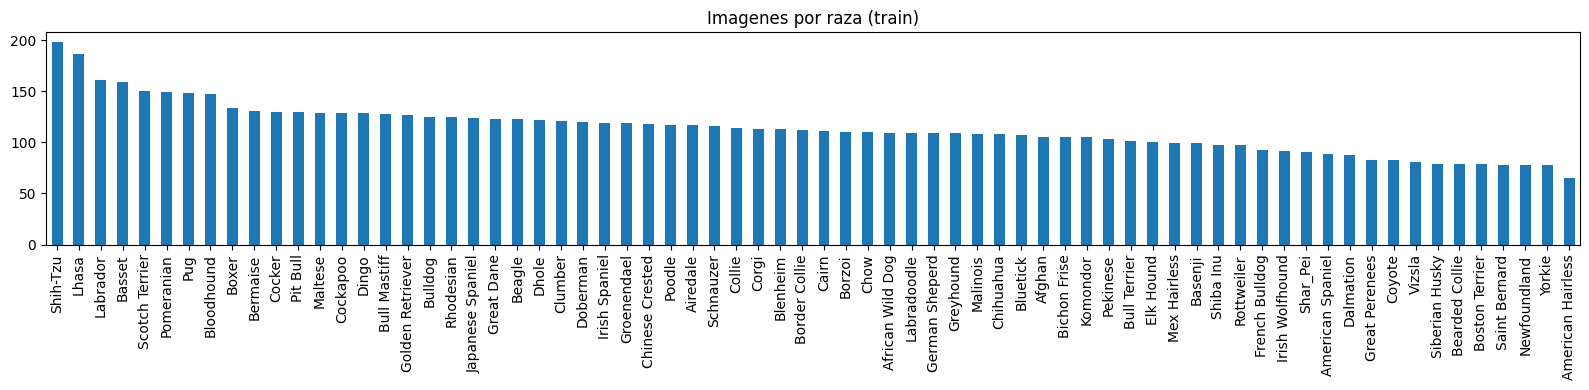

Total razas: 70
Min/Max imagenes por raza: 65 / 198


In [30]:
breeds = sorted(p.name for p in (settings.dataset_path / "train").iterdir() if p.is_dir())
counts = {b: len(list((settings.dataset_path / "train" / b).glob("*.jpg"))) for b in breeds}

df_counts = pd.Series(counts).sort_values(ascending=False)
df_counts.plot(kind="bar", figsize=(16, 4), title="Imagenes por raza (train)")
plt.tight_layout()
plt.show()

print(f"Total razas: {len(breeds)}")
print(f"Min/Max imagenes por raza: {df_counts.min()} / {df_counts.max()}")

In [31]:
from collections import Counter
from PIL import Image, UnidentifiedImageError


print(f"Promedio de imágenes por raza: {df_counts.mean():.1f}")
print(f"Desvío estándar: {df_counts.std():.1f}")
print(
    f"Razas con menos de 100 imágenes: "
    f"{(df_counts < 100).sum()} de {len(df_counts)}"
)


# Verificación completa de las dimensiones del dataset.
# Se recorren train, valid y test, en lugar de tomar únicamente
# cinco imágenes de una sola raza.
valid_extensions = {".jpg", ".jpeg", ".png"}

resolution_counts = Counter()
image_mode_counts = Counter()
images_by_split = Counter()
unreadable_images = []

for split in ("train", "valid", "test"):
    split_path = settings.dataset_path / split

    if not split_path.is_dir():
        print(f"Advertencia: no existe el conjunto '{split_path}'.")
        continue

    image_paths = sorted(
        path
        for path in split_path.rglob("*")
        if path.is_file()
        and path.suffix.lower() in valid_extensions
    )

    for img_path in image_paths:
        images_by_split[split] += 1

        try:
            # Image.open permite consultar tamaño y modo sin realizar
            # el preprocesamiento ni ejecutar el modelo.
            with Image.open(img_path) as image:
                resolution_counts[image.size] += 1
                image_mode_counts[image.mode] += 1

        except (UnidentifiedImageError, OSError) as exc:
            unreadable_images.append((img_path, str(exc)))


total_images_checked = sum(images_by_split.values())

print("\nVerificación completa de resoluciones:")
print(f"- Imágenes revisadas: {total_images_checked}")

for split, amount in images_by_split.items():
    print(f"- {split}: {amount} imágenes")

print(f"- Resoluciones diferentes: {len(resolution_counts)}")
print(f"- Modos de color encontrados: {dict(image_mode_counts)}")
print(f"- Imágenes ilegibles: {len(unreadable_images)}")


resolution_df = pd.DataFrame(
    [
        {
            "ancho": width,
            "alto": height,
            "cantidad": amount,
            "porcentaje": amount / total_images_checked * 100,
        }
        for (width, height), amount in resolution_counts.items()
    ]
).sort_values(
    by="cantidad",
    ascending=False,
).reset_index(drop=True)


print("\nResoluciones encontradas:")
display(resolution_df)


all_images_are_224 = (
    len(resolution_counts) == 1
    and resolution_counts.get((224, 224), 0)
    == total_images_checked
)

if all_images_are_224:
    print(
        "\nTodas las imágenes revisadas tienen resolución "
        "224 × 224 píxeles."
    )
else:
    print(
        "\nEl dataset no presenta una única resolución de "
        "224 × 224 píxeles. El resize sigue siendo necesario "
        "para uniformar la entrada del modelo."
    )


if unreadable_images:
    print("\nPrimeras imágenes que no pudieron abrirse:")

    for img_path, error in unreadable_images[:10]:
        print(f"- {img_path}: {error}")

Promedio de imágenes por raza: 113.5
Desvío estándar: 24.7
Razas con menos de 100 imágenes: 19 de 70

Verificación completa de resoluciones:
- Imágenes revisadas: 9346
- train: 7946 imágenes
- valid: 700 imágenes
- test: 700 imágenes
- Resoluciones diferentes: 1
- Modos de color encontrados: {'RGB': 9346}
- Imágenes ilegibles: 0

Resoluciones encontradas:


,ancho,alto,cantidad,porcentaje
0,224,224,9346,100.0



Todas las imágenes revisadas tienen resolución 224 × 224 píxeles.


**Conclusiones del análisis exploratorio:**

El dataset presenta 70 razas, con un promedio de 113,5 imágenes por raza, un desvío estándar de 24,7 y cantidades que varían entre 65 y 198 imágenes. La distribución presenta un desbalance moderado: 19 de las 70 razas tienen menos de 100 imágenes, sin observarse casos extremos de escasez.

Para analizar las dimensiones no se utiliza una muestra aislada, sino que se recorren todas las imágenes de los conjuntos `train`, `valid` y `test`. La celda anterior informa las resoluciones encontradas, su frecuencia, los modos de color y la existencia de archivos que no pudieron abrirse.

El resize a `224 × 224` se mantiene como parte necesaria del pipeline. Aunque las imágenes pudieran presentar mayoritariamente esa dimensión, la transformación garantiza una entrada uniforme y compatible con ResNet18 ante cualquier diferencia de tamaño.

### Splits provistos por el dataset

El dataset 70 Dog Breeds Image Dataset viene particionado de fabrica
en `train` (7946 imagenes), `valid` (700) y `test` (700), con las
mismas 70 razas en cada split.

In [32]:
for split in ("train", "valid", "test"):
    split_path = settings.dataset_path / split
    n_images = sum(1 for _ in split_path.rglob("*.jpg"))
    n_breeds = sum(1 for p in split_path.iterdir() if p.is_dir())
    print(f"{split}: {n_images} imagenes, {n_breeds} razas")

train: 7946 imagenes, 70 razas
valid: 700 imagenes, 70 razas
test: 700 imagenes, 70 razas


### Nota sobre Data Augmentation y filtrado de calidad

El preprocesamiento de Data Augmentation —horizontal flip, rotación, blur, variaciones de brillo y contraste o agregado de ruido— no se aplica durante la generación de la base vectorial de esta etapa. El extractor utilizado es un modelo preentrenado y congelado, y cada imagen del conjunto `train` se indexa una única vez utilizando el preprocesamiento determinista requerido por ResNet18.

No se implementa un filtrado manual de imágenes basado en criterios subjetivos de calidad. Como control básico de integridad, durante el análisis exploratorio se recorren todos los archivos de `train`, `valid` y `test`, se registran sus dimensiones y se informan las imágenes que no pueden abrirse correctamente. Esta verificación permite detectar archivos ilegibles sin eliminar automáticamente imágenes válidas por diferencias de iluminación, pose o calidad visual.

In [33]:
# Verificacion de integridad: deteccion de imagenes corruptas o ilegibles
# en una muestra del split train, que sustenta la afirmacion anterior
# sobre la calidad del dataset.
corrupt_count = 0
checked = 0
for breed in breeds[:10]:
    for img_path in (settings.dataset_path / "train" / breed).glob("*.jpg"):
        checked += 1
        img = cv2.imread(str(img_path))
        if img is None or img.size == 0:
            corrupt_count += 1
            print(f"Imagen corrupta o ilegible: {img_path}")

print(f"Imagenes verificadas: {checked}, corruptas: {corrupt_count}")

Imagenes verificadas: 1076, corruptas: 0


## 3. Implementación de `extract_embedding` y construcción de la base vectorial

### Modelo utilizado

Se utiliza **ResNet18 preentrenada en ImageNet** como extractor de características. Se elimina la capa de clasificación final (`fc`) y se conserva la salida de la capa de average pooling global, obteniendo un embedding de **512 dimensiones** para cada imagen.

La elección de ResNet18 responde a un compromiso entre capacidad de representación y costo computacional. Al utilizar pesos preentrenados en ImageNet, el modelo ya dispone de características visuales generales, como bordes, texturas, formas y patrones, que pueden aprovecharse para comparar imágenes de perros sin entrenar el extractor desde cero.

El modelo se ejecuta en modo evaluación mediante `eval()` y utiliza GPU cuando está disponible. Durante la extracción se emplea `torch.no_grad()`, ya que en esta etapa solamente se realiza inferencia y no se calculan gradientes ni se actualizan los pesos.

### Preprocesamiento aplicado

Antes de ingresar al modelo, cada imagen pasa por las siguientes transformaciones:

1. **Conversión de BGR a RGB.**
   Las imágenes se cargan con OpenCV, que utiliza el orden de canales BGR. ResNet18 fue entrenada con imágenes RGB, por lo que se realiza la conversión mediante `cv2.cvtColor`. Omitir este paso invertiría los canales de color y podría degradar la calidad de los embeddings sin producir un error de ejecución.

2. **Resize.**
   La imagen se redimensiona a `IMAGE_SIZE × IMAGE_SIZE`, cuyo valor se obtiene de la configuración del proyecto. En la configuración utilizada corresponde a **224 × 224 píxeles**, tamaño compatible con la entrada de ResNet18. El resize garantiza que todas las imágenes ingresen al modelo con dimensiones uniformes.

3. **Conversión a tensor.**
   La imagen se convierte desde una representación PIL a un tensor de PyTorch con formato `(canales, alto, ancho)`. Durante esta transformación, los valores de los píxeles pasan del rango entero `[0, 255]` al rango flotante `[0, 1]`.

4. **Normalización con estadísticas de ImageNet.**
   Se utilizan las mismas estadísticas con las que fue entrenado el modelo original:

   * Media: `[0.485, 0.456, 0.406]`
   * Desvío estándar: `[0.229, 0.224, 0.225]`

   Mantener esta normalización es necesario para que la distribución de las imágenes de entrada sea compatible con la esperada por los pesos preentrenados.

5. **Creación del batch.**
   Se agrega una dimensión inicial para representar un batch de una imagen, obteniendo un tensor con forma `(1, 3, 224, 224)`.

6. **Extracción del embedding.**
   La salida del modelo tiene inicialmente forma `(1, 512, 1, 1)`. Luego se eliminan las dimensiones unitarias y el resultado se transforma en un vector de 512 valores, que se almacena en la base vectorial junto con la ruta, la raza y la metadata de la imagen.

La implementación se encuentra en `SimilarityService.extract_embedding`, dentro de `src/lib/services/similarity_service.py`. En esta notebook se verifica la dimensión del embedding con una imagen de prueba y posteriormente se indexa el conjunto `train` mediante `scripts/build_index.py`.

In [34]:
store = build_store(settings)
similarity = build_similarity(settings, store)

sample_breed = breeds[0]
sample_path = next((settings.dataset_path / "train" / sample_breed).glob("*.jpg"))

sample_image = cv2.imread(str(sample_path))
embedding = similarity.extract_embedding(sample_image)

print(f"Raza de prueba: {sample_breed}")
print(f"Dimension del embedding: {len(embedding)}")
assert len(embedding) == settings.embedding_dim, "El embedding no coincide con EMBEDDING_DIM configurado"

INFO:lib.bootstrap:Using JSON file vector store


Raza de prueba: Afghan
Dimension del embedding: 512


In [35]:
# Esta operación recorre todas las imágenes del conjunto train,
# genera sus embeddings de manera secuencial y los almacena.
# Puede tardar varias horas, por lo que no debe ejecutarse
# accidentalmente durante cada revisión de la notebook.

RUN_FULL_INDEXING = False


if RUN_FULL_INDEXING:
    print(
        "Iniciando la indexación completa del conjunto train. "
        "El progreso se mostrará raza por raza."
    )

    subprocess.run(
        [
            sys.executable,
            "scripts/build_index.py",
            "--split",
            "train",
        ],
        check=True,
        cwd=PROJECT_ROOT,
    )

    # El script utiliza otra instancia de almacenamiento.
    # Se reconstruyen los objetos para que esta notebook consulte
    # los datos que quedaron almacenados.
    store = build_store(settings)
    similarity = build_similarity(settings, store)

    print("Indexación finalizada.")

else:
    print(
        "Indexación completa omitida para evitar repetir "
        "una operación costosa."
    )
    print(
        "Cambiar RUN_FULL_INDEXING a True solamente cuando "
        "sea necesario reconstruir la base vectorial."
    )

Indexación completa omitida para evitar repetir una operación costosa.
Cambiar RUN_FULL_INDEXING a True solamente cuando sea necesario reconstruir la base vectorial.


In [36]:
stored_records = store.all()

print("Estado de la base vectorial:")
print(f"- Registros disponibles: {len(stored_records)}")
print(
    f"- Modelo de embeddings configurado: "
    f"{settings.embedding_model}"
)

if stored_records:
    embedding_dimensions = sorted(
        {
            len(record.embedding)
            for record in stored_records
        }
    )

    indexed_breeds = {
        record.breed
        for record in stored_records
    }

    print(f"- Razas presentes: {len(indexed_breeds)}")
    print(
        f"- Dimensiones de embeddings encontradas: "
        f"{embedding_dimensions}"
    )
else:
    print(
        "- La base está vacía. Las búsquedas no podrán "
        "evaluarse hasta construir el índice."
    )

Estado de la base vectorial:
- Registros disponibles: 7946
- Modelo de embeddings configurado: baseline
- Razas presentes: 70
- Dimensiones de embeddings encontradas: [512]


## 4. Busqueda por similitud y prediccion de raza

`search_similar_images` y `predict_breed_from_neighbors` se ejercitan
aqui sobre una imagen de prueba del split `test`, distinta de las
indexadas en el paso anterior.

In [37]:
query_breed = breeds[0]
query_path = next((settings.dataset_path / "test" / query_breed).glob("*.jpg"))

result_path = similarity.search(
    source_path=str(query_path),
    output_path=settings.output_path,
)

result = json.loads(Path(result_path).read_text(encoding="utf-8"))

print(f"Raza real: {query_breed}")
print(f"Raza predicha: {result['predicted_breed']} (score={result['score']})")
print(f"Vecinos recuperados: {len(result['neighbors'])}")
for n in result["neighbors"][:5]:
    print(f"  - {n['breed']} (score={n['score']})")

INFO:lib.services.similarity_service:Predicted breed: Afghan (score=0.8690) for data\dataset\test\Afghan\01.jpg


Raza real: Afghan
Raza predicha: Afghan (score=0.869)
Vecinos recuperados: 10
  - Afghan (score=0.869)
  - Afghan (score=0.8642)
  - Afghan (score=0.8629)
  - Afghan (score=0.8599)
  - Afghan (score=0.8582)


## 5. Evaluacion: NDCG@10

Para cada imagen del conjunto de test se ejecuta la busqueda completa,
se recuperan los Top-10 vecinos y se calcula NDCG@10, usando como
relevancia binaria si la raza del vecino coincide con la raza real de
la imagen consultada.

In [38]:
from collections import Counter


def dcg_at_k(relevances: list[int], k: int) -> float:
    """
    Calcula Discounted Cumulative Gain hasta la posición k.

    La relevancia es binaria:
    - 1: el vecino pertenece a la raza correcta.
    - 0: el vecino pertenece a otra raza.
    """
    relevances_at_k = np.asarray(relevances[:k], dtype=np.float64)

    if relevances_at_k.size == 0:
        return 0.0

    discounts = np.log2(np.arange(2, relevances_at_k.size + 2))
    return float(np.sum(relevances_at_k / discounts))


def ndcg_at_k(
    relevances: list[int],
    k: int,
    total_relevant: int,
) -> float:
    """
    Calcula NDCG@k comparando el ranking recuperado con el mejor
    ranking posible dentro de la base indexada.

    total_relevant indica cuántas imágenes de la raza correcta
    existen realmente en la base de búsqueda.
    """
    dcg = dcg_at_k(relevances, k)

    ideal_relevant_count = min(total_relevant, k)
    ideal_relevances = [1] * ideal_relevant_count

    idcg = dcg_at_k(ideal_relevances, k)

    return dcg / idcg if idcg > 0 else 0.0


# Se cuentan las imágenes realmente almacenadas en la base vectorial.
# Esto es más preciso que usar directamente la cantidad de archivos
# del dataset, porque alguna imagen podría no haber sido indexada.
indexed_records = store.all()
indexed_breed_counts = Counter(record.breed for record in indexed_records)

ndcg_scores = []

for breed in breeds:
    test_images = list(
        (settings.dataset_path / "test" / breed).glob("*.jpg")
    )

    total_relevant = indexed_breed_counts.get(breed, 0)

    for img_path in test_images:
        image = cv2.imread(str(img_path))

        if image is None:
            print(f"Imagen ilegible, se omite: {img_path}")
            continue

        embedding = similarity.extract_embedding(image)

        neighbors = similarity.search_similar_images(
            embedding,
            top_k=10,
        )

        relevances = [
            1 if neighbor.breed == breed else 0
            for neighbor in neighbors
        ]

        score = ndcg_at_k(
            relevances=relevances,
            k=10,
            total_relevant=total_relevant,
        )

        ndcg_scores.append(score)


if ndcg_scores:
    print(f"NDCG@10 promedio: {np.mean(ndcg_scores):.4f}")
    print(f"Imágenes evaluadas: {len(ndcg_scores)}")
else:
    print("No se pudieron evaluar imágenes del conjunto de test.")

NDCG@10 promedio: 0.8768
Imágenes evaluadas: 700


In [39]:
from IPython.display import Markdown, display


if ndcg_scores:
    ndcg_mean = float(np.mean(ndcg_scores))
    ndcg_median = float(np.median(ndcg_scores))
    evaluated_images = len(ndcg_scores)

    perfect_rankings = int(
        np.sum(np.isclose(ndcg_scores, 1.0))
    )

    perfect_percentage = (
        perfect_rankings / evaluated_images * 100
    )

    display(
        Markdown(
            f"""
**Análisis del resultado obtenido:**

Se evaluaron **{evaluated_images} imágenes** del conjunto de prueba mediante
búsqueda por similitud con `top_k=10`. El sistema obtuvo un
**NDCG@10 promedio de {ndcg_mean:.4f}** y una mediana de
**{ndcg_median:.4f}**.

En **{perfect_rankings} consultas ({perfect_percentage:.2f} %)**, los diez
primeros vecinos recuperados pertenecieron a la misma raza que la imagen
consultada, obteniéndose un NDCG@10 igual a 1.

NDCG@10 evalúa simultáneamente la relevancia y la posición de los resultados
recuperados. Un valor igual a 1 representa el ranking ideal, mientras que los
valores menores indican que aparecen imágenes de otras razas dentro de los
primeros diez resultados o que los resultados relevantes ocupan posiciones
más bajas.

El resultado corresponde a embeddings generados mediante una ResNet18
preentrenada en ImageNet, sin fine-tuning específico sobre las razas del
dataset. Por lo tanto, permite evaluar hasta qué punto las características
visuales generales aprendidas por el modelo resultan útiles para la recuperación
por similitud.

La métrica global no demuestra que todas las razas estén perfectamente
separadas ni permite identificar por sí sola cuáles generan confusiones. Para
determinarlo sería necesario analizar los rankings con menor NDCG y observar
qué razas aparecen entre sus vecinos.
"""
        )
    )

else:
    display(
        Markdown(
            """
**Análisis del resultado obtenido:**

No se obtuvieron resultados válidos para calcular NDCG@10. Debe verificarse
que el conjunto de prueba contenga imágenes legibles y que la base vectorial
haya sido construida correctamente.
"""
        )
    )
    


**Análisis del resultado obtenido:**

Se evaluaron **700 imágenes** del conjunto de prueba mediante
búsqueda por similitud con `top_k=10`. El sistema obtuvo un
**NDCG@10 promedio de 0.8768** y una mediana de
**1.0000**.

En **393 consultas (56.14 %)**, los diez
primeros vecinos recuperados pertenecieron a la misma raza que la imagen
consultada, obteniéndose un NDCG@10 igual a 1.

NDCG@10 evalúa simultáneamente la relevancia y la posición de los resultados
recuperados. Un valor igual a 1 representa el ranking ideal, mientras que los
valores menores indican que aparecen imágenes de otras razas dentro de los
primeros diez resultados o que los resultados relevantes ocupan posiciones
más bajas.

El resultado corresponde a embeddings generados mediante una ResNet18
preentrenada en ImageNet, sin fine-tuning específico sobre las razas del
dataset. Por lo tanto, permite evaluar hasta qué punto las características
visuales generales aprendidas por el modelo resultan útiles para la recuperación
por similitud.

La métrica global no demuestra que todas las razas estén perfectamente
separadas ni permite identificar por sí sola cuáles generan confusiones. Para
determinarlo sería necesario analizar los rankings con menor NDCG y observar
qué razas aparecen entre sus vecinos.


### Evaluación con datos externos al dataset:

In [40]:
external_ndcg_scores = []
valid_extensions = {".jpg", ".jpeg", ".png"}

if EXTERNAL_SET_PATH.is_dir():
    for breed_dir in sorted(EXTERNAL_SET_PATH.iterdir()):
        if not breed_dir.is_dir():
            continue

        breed_name = breed_dir.name
        total_relevant = indexed_breed_counts.get(breed_name, 0)

        if total_relevant == 0:
            print(
                f"Advertencia: la raza '{breed_name}' no existe "
                "en la base vectorial y se omite."
            )
            continue

        image_paths = sorted(
            path
            for path in breed_dir.glob("*")
            if path.suffix.lower() in valid_extensions
        )

        for img_path in image_paths:
            image = cv2.imread(str(img_path))

            if image is None:
                print(f"Imagen ilegible, se omite: {img_path}")
                continue

            embedding = similarity.extract_embedding(image)

            neighbors = similarity.search_similar_images(
                embedding,
                top_k=10,
            )

            relevances = [
                1 if neighbor.breed == breed_name else 0
                for neighbor in neighbors
            ]

            score = ndcg_at_k(
                relevances=relevances,
                k=10,
                total_relevant=total_relevant,
            )

            external_ndcg_scores.append(score)

    if external_ndcg_scores:
        print("Métricas del conjunto externo de evaluación:")
        print(
            f"Total de imágenes evaluadas: "
            f"{len(external_ndcg_scores)}"
        )
        print(
            f"NDCG@10 promedio externo: "
            f"{np.mean(external_ndcg_scores):.4f}"
        )
    else:
        print(
            "No se encontraron imágenes externas válidas "
            "para evaluar."
        )
else:
    print(
        f"No existe el directorio del conjunto externo: "
        f"{EXTERNAL_SET_PATH}"
    )

Métricas del conjunto externo de evaluación:
Total de imágenes evaluadas: 26
NDCG@10 promedio externo: 0.5298


In [41]:
from IPython.display import Markdown, display


if external_ndcg_scores:
    external_ndcg_mean = float(
        np.mean(external_ndcg_scores)
    )

    external_ndcg_median = float(
        np.median(external_ndcg_scores)
    )

    external_evaluated_images = len(
        external_ndcg_scores
    )

    external_perfect_rankings = int(
        np.sum(
            np.isclose(
                external_ndcg_scores,
                1.0,
            )
        )
    )

    external_perfect_percentage = (
        external_perfect_rankings
        / external_evaluated_images
        * 100
    )

    display(
        Markdown(
            f"""
**Análisis del conjunto externo:**

Se evaluaron **{external_evaluated_images} imágenes externas**, no pertenecientes
al dataset utilizado para construir la base vectorial. El sistema obtuvo un
**NDCG@10 promedio de {external_ndcg_mean:.4f}** y una mediana de
**{external_ndcg_median:.4f}**.

En **{external_perfect_rankings} consultas
({external_perfect_percentage:.2f} %)**, las diez primeras imágenes recuperadas
pertenecieron a la misma raza que la consulta.

Este conjunto permite observar el comportamiento del sistema frente a imágenes
obtenidas fuera del dataset principal, que pueden presentar diferencias de
iluminación, fondo, pose, encuadre o calidad. Por esa razón, su resultado no debe
compararse únicamente como una medida de rendimiento absoluto, sino también
como una aproximación a la capacidad de generalización del extractor.

El tamaño reducido del conjunto externo limita el alcance de las conclusiones.
El resultado permite detectar una posible diferencia respecto del conjunto de
prueba interno, pero no alcanza para afirmar por sí solo que exista una falla
sistemática del modelo.
"""
        )
    )

else:
    display(
        Markdown(
            """
**Análisis del conjunto externo:**

No se obtuvieron resultados válidos para calcular NDCG@10 sobre el conjunto
externo. Debe verificarse que el directorio exista, que las imágenes puedan
abrirse correctamente y que los nombres de las carpetas coincidan con las razas
almacenadas en la base vectorial.
"""
        )
    )


**Análisis del conjunto externo:**

Se evaluaron **26 imágenes externas**, no pertenecientes
al dataset utilizado para construir la base vectorial. El sistema obtuvo un
**NDCG@10 promedio de 0.5298** y una mediana de
**0.5997**.

En **3 consultas
(11.54 %)**, las diez primeras imágenes recuperadas
pertenecieron a la misma raza que la consulta.

Este conjunto permite observar el comportamiento del sistema frente a imágenes
obtenidas fuera del dataset principal, que pueden presentar diferencias de
iluminación, fondo, pose, encuadre o calidad. Por esa razón, su resultado no debe
compararse únicamente como una medida de rendimiento absoluto, sino también
como una aproximación a la capacidad de generalización del extractor.

El tamaño reducido del conjunto externo limita el alcance de las conclusiones.
El resultado permite detectar una posible diferencia respecto del conjunto de
prueba interno, pero no alcanza para afirmar por sí solo que exista una falla
sistemática del modelo.


## 6. Visualizacion de embeddings (PCA / t-SNE)

Proyeccion a 2 dimensiones de los embeddings indexados (split train),
coloreada por raza, para observar si el espacio de embeddings agrupa
visualmente razas similares entre si.

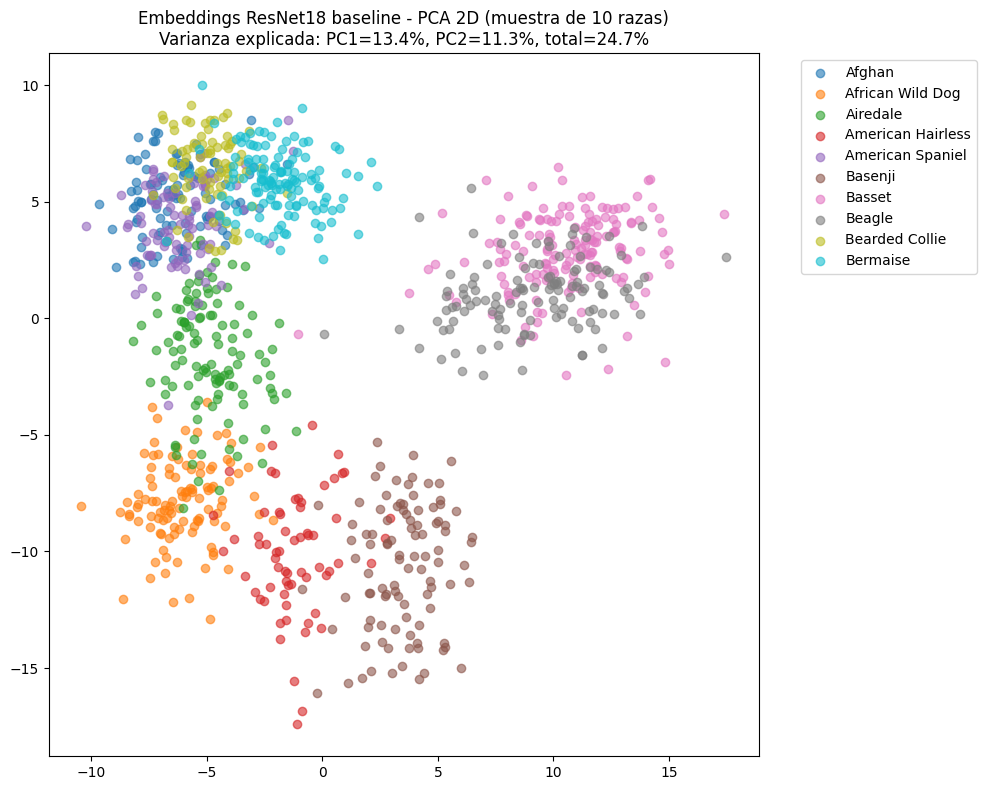

Varianza explicada por componente: [0.13380634 0.11344689]
Varianza total explicada (2 componentes): 24.7%


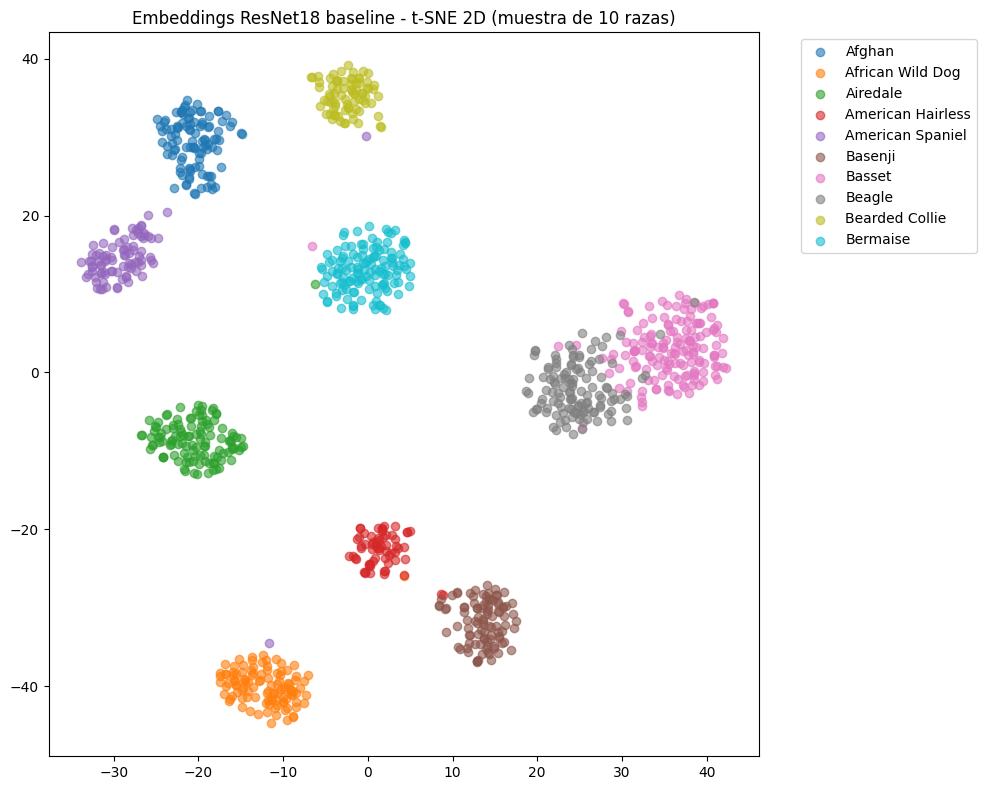

In [42]:
all_records = store.all()
embeddings_matrix = np.array([r.embedding for r in all_records])
breed_labels = [r.breed for r in all_records]

sample_breeds = breeds[:10]
mask = [b in sample_breeds for b in breed_labels]
X_sample = embeddings_matrix[mask]
labels_sample = np.array(breed_labels)[mask]

# --- PCA ---
pca = PCA(n_components=2)
coords_pca = pca.fit_transform(X_sample)
var_explicada = pca.explained_variance_ratio_

plt.figure(figsize=(10, 8))
for breed in sample_breeds:
    breed_mask = labels_sample == breed
    plt.scatter(coords_pca[breed_mask, 0], coords_pca[breed_mask, 1], label=breed, alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title(
    f"Embeddings ResNet18 baseline - PCA 2D (muestra de 10 razas)\n"
    f"Varianza explicada: PC1={var_explicada[0]:.1%}, PC2={var_explicada[1]:.1%}, "
    f"total={var_explicada.sum():.1%}"
)
plt.tight_layout()
plt.show()

print(f"Varianza explicada por componente: {var_explicada}")
print(f"Varianza total explicada (2 componentes): {var_explicada.sum():.1%}")

# --- t-SNE ---
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
coords_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10, 8))
for breed in sample_breeds:
    breed_mask = labels_sample == breed
    plt.scatter(coords_tsne[breed_mask, 0], coords_tsne[breed_mask, 1], label=breed, alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Embeddings ResNet18 baseline - t-SNE 2D (muestra de 10 razas)")
plt.tight_layout()
plt.show()

**Interpretación de los gráficos:**

La proyección mediante PCA conserva aproximadamente el 24,7 % de la varianza total en sus dos primeros componentes —13,4 % en el primero y 11,3 % en el segundo—. Por lo tanto, esta representación bidimensional resume solamente una parte del espacio original de 512 dimensiones.

La superposición observada entre algunas razas en PCA no permite concluir, por sí sola, que sus embeddings sean indistinguibles. La reducción a dos componentes lineales implica una pérdida considerable de información y se utiliza principalmente como una aproximación visual global del espacio.

En la proyección mediante t-SNE, la mayoría de las diez razas seleccionadas forma agrupaciones visualmente diferenciadas. Sin embargo, también se observa cierta proximidad o superposición entre algunas razas —particularmente entre Basset y Beagle—, además de algunos puntos aislados respecto de sus agrupaciones principales.

Este resultado sugiere que los embeddings conservan información útil para agrupar visualmente varias de las razas analizadas, pero no demuestra una separación perfecta. Además, la visualización corresponde únicamente a una muestra de diez razas y no permite generalizar directamente el comportamiento al conjunto completo de setenta clases.

PCA y t-SNE se utilizan aquí como herramientas de análisis cualitativo. El desempeño del buscador debe evaluarse principalmente mediante la métrica NDCG@10 calculada sobre el conjunto de prueba, mientras que estas proyecciones ayudan a interpretar visualmente la estructura de los embeddings.

In [43]:
from IPython.display import Markdown, display


internal_scores = globals().get("ndcg_scores", [])
external_scores = globals().get("external_ndcg_scores", [])
pca_variance = globals().get("var_explicada", None)


conclusion_parts = [
    "## Conclusión general — Etapa 1",
    "",
    (
        "En esta etapa se implementó un sistema de búsqueda de imágenes "
        "por similitud utilizando embeddings de 512 dimensiones generados "
        "mediante una ResNet18 preentrenada en ImageNet. El modelo se empleó "
        "como extractor congelado, sin fine-tuning específico sobre el "
        "dataset de razas de perros."
    ),
    "",
    (
        "Las imágenes del conjunto `train` se utilizaron para construir la "
        "base vectorial, mientras que las consultas de evaluación se "
        "realizaron con imágenes no indexadas del conjunto `test`. Para cada "
        "consulta se recuperaron los diez vecinos más cercanos y se predijo "
        "la raza a partir de los resultados obtenidos."
    ),
]


if internal_scores:
    internal_mean = float(np.mean(internal_scores))
    internal_median = float(np.median(internal_scores))
    internal_count = len(internal_scores)

    conclusion_parts.extend(
        [
            "",
            (
                f"Sobre el conjunto de prueba se evaluaron "
                f"**{internal_count} imágenes**, obteniéndose un "
                f"**NDCG@10 promedio de {internal_mean:.4f}** y una "
                f"mediana de **{internal_median:.4f}**. Este resultado "
                f"mide la capacidad del sistema para ubicar imágenes de "
                f"la raza correcta entre las primeras posiciones del ranking."
            ),
        ]
    )

else:
    conclusion_parts.extend(
        [
            "",
            (
                "No se obtuvo una evaluación válida sobre el conjunto de "
                "prueba. Debe verificarse la construcción de la base "
                "vectorial y volver a ejecutar el cálculo de NDCG@10."
            ),
        ]
    )


if external_scores:
    external_mean = float(np.mean(external_scores))
    external_median = float(np.median(external_scores))
    external_count = len(external_scores)

    conclusion_parts.extend(
        [
            "",
            (
                f"También se evaluaron **{external_count} imágenes externas**, "
                f"pertenecientes a cinco razas y no incluidas en el dataset "
                f"principal. En este conjunto se obtuvo un "
                f"**NDCG@10 promedio de {external_mean:.4f}** y una mediana "
                f"de **{external_median:.4f}**."
            ),
            "",
            (
                "La comparación entre ambos resultados debe interpretarse "
                "con cautela. El conjunto externo es considerablemente más "
                "pequeño, incluye solamente cinco de las setenta razas y "
                "puede presentar condiciones visuales diferentes. Por lo "
                "tanto, permite observar el comportamiento del sistema fuera "
                "del dataset principal, pero no alcanza para establecer por "
                "sí solo las causas de una diferencia de rendimiento."
            ),
        ]
    )

else:
    conclusion_parts.extend(
        [
            "",
            (
                "No se obtuvo una evaluación válida sobre el conjunto externo. "
                "Debe verificarse la disponibilidad de sus imágenes y la "
                "coincidencia entre los nombres de sus carpetas y las razas "
                "indexadas."
            ),
        ]
    )


if pca_variance is not None:
    total_pca_variance = float(np.sum(pca_variance))

    conclusion_parts.extend(
        [
            "",
            (
                f"La proyección PCA en dos dimensiones conservó aproximadamente "
                f"el **{total_pca_variance:.1%} de la varianza** de la muestra "
                f"analizada. Debido a esta reducción, la superposición visible "
                f"en el gráfico no representa necesariamente toda la estructura "
                f"del espacio original de 512 dimensiones."
            ),
        ]
    )


conclusion_parts.extend(
    [
        "",
        (
            "La visualización mediante t-SNE mostró agrupamientos reconocibles "
            "para la mayoría de las diez razas seleccionadas, aunque también "
            "se observaron zonas de proximidad y algunos puntos aislados. Estas "
            "proyecciones se utilizan como apoyo cualitativo y no reemplazan la "
            "evaluación cuantitativa mediante NDCG@10."
        ),
        "",
        (
            "En conjunto, la etapa permite establecer un baseline basado en "
            "características preentrenadas. Sus resultados sirven como punto "
            "de comparación para evaluar posteriormente si un modelo ajustado "
            "específicamente al dominio de razas de perros mejora la "
            "clasificación y la recuperación por similitud."
        ),
    ]
)


display(
    Markdown(
        "\n".join(conclusion_parts)
    )
)

## Conclusión general — Etapa 1

En esta etapa se implementó un sistema de búsqueda de imágenes por similitud utilizando embeddings de 512 dimensiones generados mediante una ResNet18 preentrenada en ImageNet. El modelo se empleó como extractor congelado, sin fine-tuning específico sobre el dataset de razas de perros.

Las imágenes del conjunto `train` se utilizaron para construir la base vectorial, mientras que las consultas de evaluación se realizaron con imágenes no indexadas del conjunto `test`. Para cada consulta se recuperaron los diez vecinos más cercanos y se predijo la raza a partir de los resultados obtenidos.

Sobre el conjunto de prueba se evaluaron **700 imágenes**, obteniéndose un **NDCG@10 promedio de 0.8768** y una mediana de **1.0000**. Este resultado mide la capacidad del sistema para ubicar imágenes de la raza correcta entre las primeras posiciones del ranking.

También se evaluaron **26 imágenes externas**, pertenecientes a cinco razas y no incluidas en el dataset principal. En este conjunto se obtuvo un **NDCG@10 promedio de 0.5298** y una mediana de **0.5997**.

La comparación entre ambos resultados debe interpretarse con cautela. El conjunto externo es considerablemente más pequeño, incluye solamente cinco de las setenta razas y puede presentar condiciones visuales diferentes. Por lo tanto, permite observar el comportamiento del sistema fuera del dataset principal, pero no alcanza para establecer por sí solo las causas de una diferencia de rendimiento.

La proyección PCA en dos dimensiones conservó aproximadamente el **24.7% de la varianza** de la muestra analizada. Debido a esta reducción, la superposición visible en el gráfico no representa necesariamente toda la estructura del espacio original de 512 dimensiones.

La visualización mediante t-SNE mostró agrupamientos reconocibles para la mayoría de las diez razas seleccionadas, aunque también se observaron zonas de proximidad y algunos puntos aislados. Estas proyecciones se utilizan como apoyo cualitativo y no reemplazan la evaluación cuantitativa mediante NDCG@10.

En conjunto, la etapa permite establecer un baseline basado en características preentrenadas. Sus resultados sirven como punto de comparación para evaluar posteriormente si un modelo ajustado específicamente al dominio de razas de perros mejora la clasificación y la recuperación por similitud.